# YOLO Model Comparison: `results11s` vs `results26x`

This notebook compares object-detection counts produced by two different YOLO models (e.g. an `8s` and a `26x` variant) run over the **same dataset**. Since both CSVs contain one row per frame with identical filenames and identical order, we can compare them frame-by-frame and class-by-class.

**What this notebook covers:**
1. Loading & sanity-checking the data
2. Overall totals per class (which model detects more?)
3. Per-frame differences & agreement statistics (MAE, RMSE, correlation)
4. Distributions of differences per class
5. Scatter plots: model A count vs. model B count
6. Frames with the largest disagreement
7. Time-based view (using the `timestamp` column)
8. Summary table & exportable results

> Adjust `FILE_A` / `FILE_B` and `LABEL_A` / `LABEL_B` in the first code cell if your filenames differ.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# ---- Config: adjust paths/labels here ----
FILE_A = "/content/drive/MyDrive/datasets/results11s_Freitag.csv"
FILE_B = "/content/drive/MyDrive/datasets/results2_reviewed.csv"
LABEL_A = "YOLOv11s"
LABEL_B = "Labeled"
# -------------------------------------------

## 1. Load & sanity-check data

In [3]:
df_a = pd.read_csv(FILE_A, parse_dates=["timestamp"])
df_b = pd.read_csv(FILE_B, parse_dates=["timestamp"])

print(f"{LABEL_A}: {df_a.shape[0]} rows, {df_a.shape[1]} columns")
print(f"{LABEL_B}: {df_b.shape[0]} rows, {df_b.shape[1]} columns")

df_a.head()

YOLOv11s: 1001 rows, 7 columns
Labeled: 1001 rows, 8 columns


,filename,person,bicycle,motorcycle,car,traffic light,timestamp
0,DJI_0392_frame_00000.jpg,0,0,0,0,0,2026-07-24 13:12:13
1,DJI_0392_frame_00001.jpg,0,0,0,10,1,2026-07-24 13:06:40
2,DJI_0392_frame_00002.jpg,1,0,0,2,0,2026-07-24 13:06:40
3,DJI_0392_frame_00003.jpg,1,0,0,9,1,2026-07-24 13:06:41
4,DJI_0392_frame_00004.jpg,5,1,0,5,0,2026-07-24 13:06:41


In [4]:
# Class columns = everything except filename/timestamp
meta_cols = ["filename", "timestamp"]
KEEP_CLASSES = ["bicycle", "car", "traffic light"]   # <-- only these get analyzed
class_cols = [c for c in df_a.columns if c not in meta_cols and c in KEEP_CLASSES]
print("Detected classes:", class_cols)

# Sanity check: same frames, same order, in both files
assert list(df_a["filename"]) == list(df_b["filename"]), \
    "Row order/filenames differ between the two files — merge on 'filename' instead of assuming order."
print("Row order matches between both files ✔")

Detected classes: ['bicycle', 'car', 'traffic light']
Row order matches between both files ✔


## 2. Merge into one long/wide comparison frame

We build a single wide dataframe with suffixes `_a` / `_b`, plus a per-class **difference** (`b - a`) so positive values mean model B (26x) detected more objects than model A (8s) on that frame.

In [5]:
df = df_a.merge(df_b, on="filename", suffixes=("_a", "_b"))
df["timestamp"] = df["timestamp_a"]
df = df.drop(columns=["timestamp_a", "timestamp_b"])

for c in class_cols:
    df[f"{c}_diff"] = df[f"{c}_b"] - df[f"{c}_a"]

df.head()

,filename,person_a,bicycle_a,motorcycle_a,car_a,traffic light_a,person_b,bicycle_b,motorcycle_b,car_b,traffic light_b,review_status,timestamp,bicycle_diff,car_diff,traffic light_diff
0,DJI_0392_frame_00000.jpg,0,0,0,0,0,0,0,0,0,0,confirmed,2026-07-24 13:12:13,0,0,0
1,DJI_0392_frame_00001.jpg,0,0,0,10,1,0,0,0,10,2,corrected,2026-07-24 13:06:40,0,0,1
2,DJI_0392_frame_00002.jpg,1,0,0,2,0,1,0,0,3,0,confirmed,2026-07-24 13:06:40,0,1,0
3,DJI_0392_frame_00003.jpg,1,0,0,9,1,1,0,0,8,4,corrected,2026-07-24 13:06:41,0,-1,3
4,DJI_0392_frame_00004.jpg,5,1,0,5,0,7,2,0,7,0,corrected,2026-07-24 13:06:41,1,2,0


## 3. Overall totals per class

How many objects did each model detect in total, across the whole dataset?

In [6]:
totals = pd.DataFrame({
    LABEL_A: [df_a[c].sum() for c in class_cols],
    LABEL_B: [df_b[c].sum() for c in class_cols],
}, index=class_cols)
totals["diff (B-A)"] = totals[LABEL_B] - totals[LABEL_A]
totals["pct_diff (%)"] = (totals["diff (B-A)"] / totals[LABEL_A].replace(0, np.nan) * 100).round(1)
totals

,YOLOv11s,Labeled,diff (B-A),pct_diff (%)
bicycle,189,255,66,34.9
car,1075,1290,215,20.0
traffic light,110,132,22,20.0


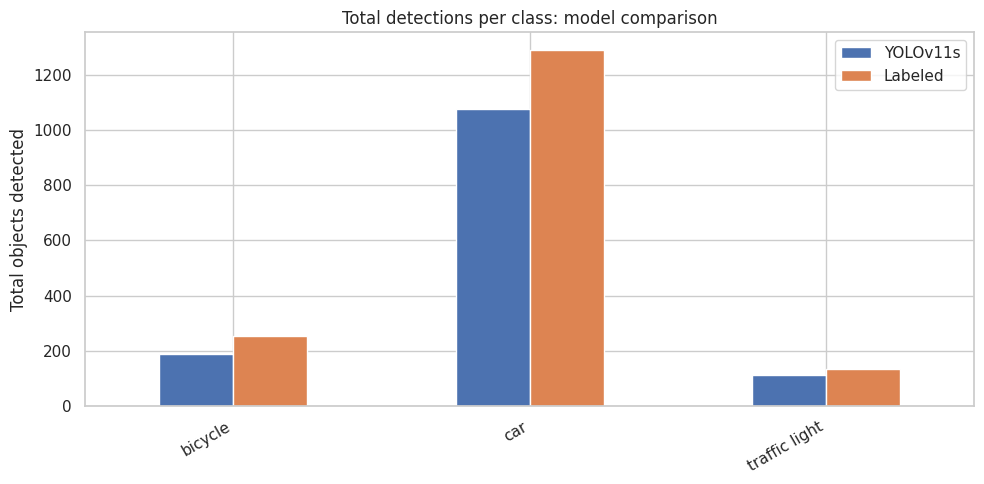

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
totals[[LABEL_A, LABEL_B]].plot(kind="bar", ax=ax)
ax.set_ylabel("Total objects detected")
ax.set_title("Total detections per class: model comparison")
ax.set_xticklabels(class_cols, rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4. Per-frame agreement statistics

For each class we compute:
- **Mean Absolute Error (MAE):** average absolute count difference per frame
- **Mean Signed Difference (bias):** does one model systematically over/under count?
- **RMSE:** penalizes large disagreements more heavily
- **Pearson correlation:** how consistently do the two models move together?
- **Exact-match rate:** fraction of frames where both models report identical counts

In [8]:
def agreement_stats(df, class_cols):
    rows = []
    for c in class_cols:
        a = df[f"{c}_a"]
        b = df[f"{c}_b"]
        diff = b - a
        rows.append({
            "class": c,
            "MAE": diff.abs().mean(),
            "mean_signed_diff": diff.mean(),
            "RMSE": np.sqrt((diff ** 2).mean()),
            "pearson_r": a.corr(b),
            "exact_match_rate": (diff == 0).mean(),
        })
    return pd.DataFrame(rows).set_index("class").round(3)

stats_df = agreement_stats(df, class_cols)
stats_df

,MAE,mean_signed_diff,RMSE,pearson_r,exact_match_rate
class,,,,,
bicycle,0.120,0.066,0.451,0.806,0.909
car,0.281,0.215,0.796,0.952,0.818
traffic light,0.054,0.022,0.300,0.873,0.960


## 5. Distribution of per-frame differences (per class)

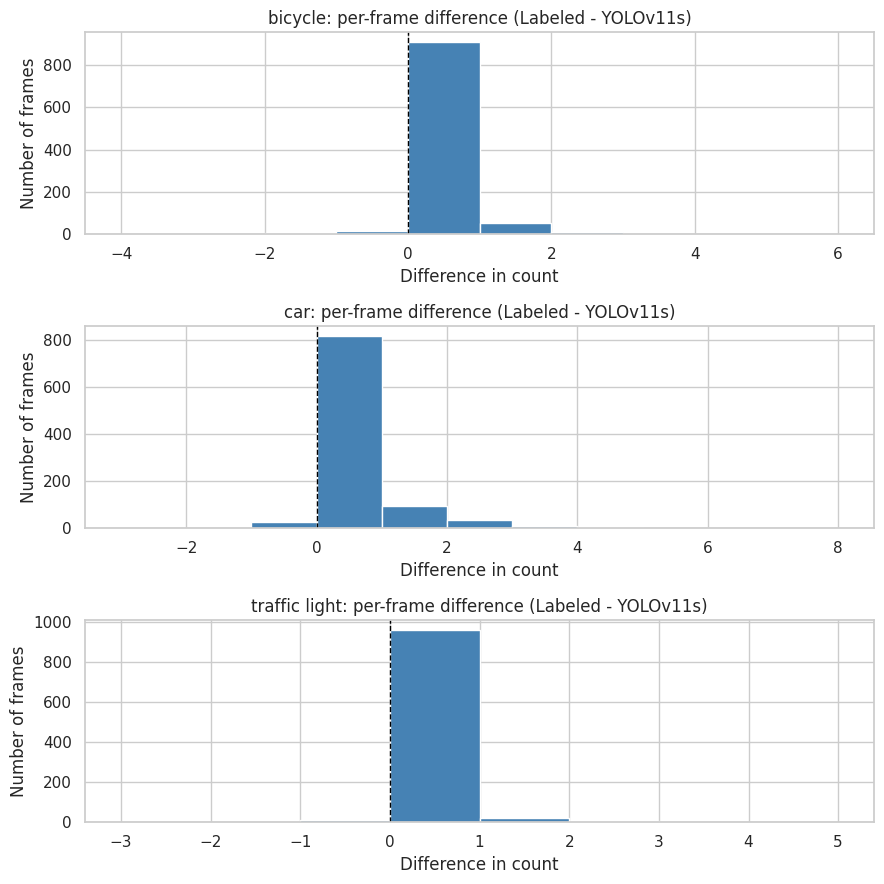

In [9]:
fig, axes = plt.subplots(len(class_cols), 1, figsize=(9, 3 * len(class_cols)), sharex=False)
if len(class_cols) == 1:
    axes = [axes]

for ax, c in zip(axes, class_cols):
    diff = df[f"{c}_diff"]
    bins = range(int(diff.min()) - 1, int(diff.max()) + 2)
    ax.hist(diff, bins=bins, color="steelblue", edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{c}: per-frame difference ({LABEL_B} - {LABEL_A})")
    ax.set_xlabel("Difference in count")
    ax.set_ylabel("Number of frames")

plt.tight_layout()
plt.show()

## 6. Scatter plots: Model A count vs. Model B count

Points on the diagonal line mean perfect agreement for that frame.

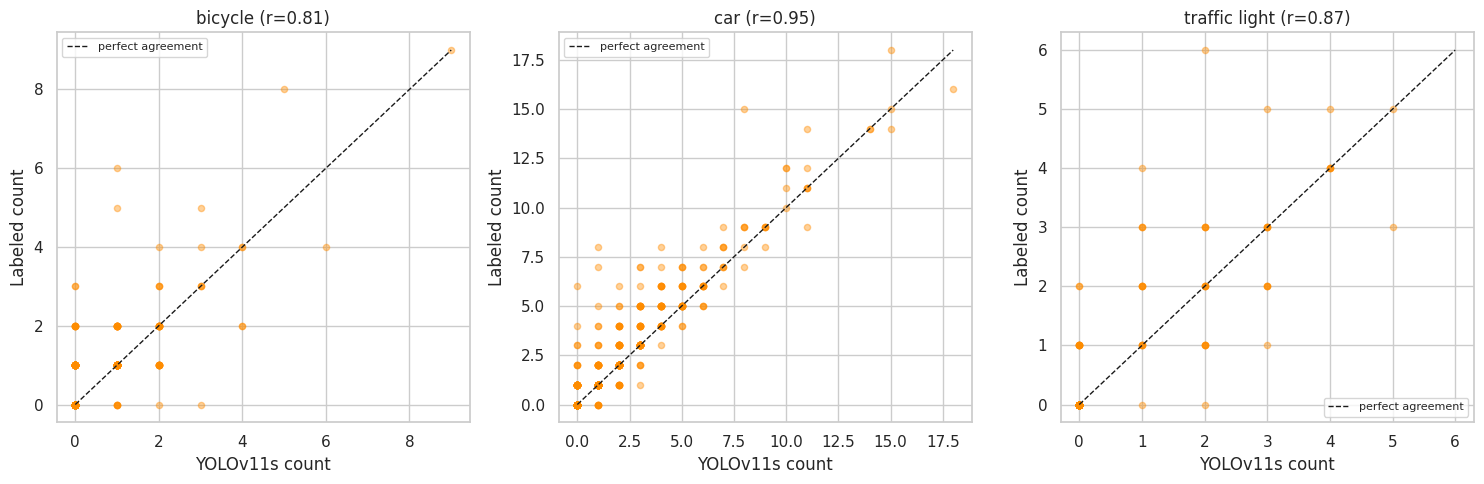

In [10]:
n = len(class_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.array(axes).reshape(-1)

for i, c in enumerate(class_cols):
    ax = axes[i]
    a = df[f"{c}_a"]
    b = df[f"{c}_b"]
    max_val = max(a.max(), b.max(), 1)
    ax.scatter(a, b, alpha=0.4, s=20, color="darkorange")
    ax.plot([0, max_val], [0, max_val], "k--", linewidth=1, label="perfect agreement")
    ax.set_xlabel(f"{LABEL_A} count")
    ax.set_ylabel(f"{LABEL_B} count")
    ax.set_title(f"{c} (r={stats_df.loc[c, 'pearson_r']:.2f})")
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 7. Frames with the largest disagreement

A quick way to spot frames worth manually inspecting (e.g. open the image and see which model is right).

In [11]:
TOP_N = 10

for c in class_cols:
    print(f"\n--- Top {TOP_N} frames by absolute disagreement: {c} ---")
    top = df.reindex(df[f"{c}_diff"].abs().sort_values(ascending=False).index).head(TOP_N)
    display(top[["filename", f"{c}_a", f"{c}_b", f"{c}_diff", "timestamp"]]
            .rename(columns={f"{c}_a": LABEL_A, f"{c}_b": LABEL_B}))


--- Top 10 frames by absolute disagreement: bicycle ---


,filename,YOLOv11s,Labeled,bicycle_diff,timestamp
188,DJI_0394_frame_00004.jpg,1,6,5,2026-07-24 13:11:23
870,DJI_0402_frame_00029.jpg,1,5,4,2026-07-24 13:12:03
261,DJI_0395_frame_00014.jpg,5,8,3,2026-07-24 13:11:27
526,DJI_0398_frame_00060.jpg,0,3,3,2026-07-24 13:11:44
34,DJI_0392_frame_00036.jpg,0,3,3,2026-07-24 13:11:13
975,DJI_0403_frame_00039.jpg,3,0,-3,2026-07-24 13:12:11
985,DJI_0403_frame_00049.jpg,4,2,-2,2026-07-24 13:12:11
21,DJI_0392_frame_00023.jpg,6,4,-2,2026-07-24 13:11:13
892,DJI_0402_frame_00051.jpg,4,2,-2,2026-07-24 13:12:04
14,DJI_0392_frame_00016.jpg,2,4,2,2026-07-24 13:11:13



--- Top 10 frames by absolute disagreement: car ---


,filename,YOLOv11s,Labeled,car_diff,timestamp
31,DJI_0392_frame_00033.jpg,8,15,7,2026-07-24 13:11:13
274,DJI_0395_frame_00027.jpg,1,8,7,2026-07-24 13:11:28
345,DJI_0396_frame_00005.jpg,0,6,6,2026-07-24 13:11:31
273,DJI_0395_frame_00026.jpg,1,7,6,2026-07-24 13:11:28
347,DJI_0396_frame_00007.jpg,4,8,4,2026-07-24 13:11:31
263,DJI_0395_frame_00016.jpg,2,6,4,2026-07-24 13:11:27
266,DJI_0395_frame_00019.jpg,0,4,4,2026-07-24 13:11:27
591,DJI_0399_frame_00032.jpg,3,7,4,2026-07-24 13:11:48
180,DJI_0393_frame_00089.jpg,1,5,4,2026-07-24 13:11:23
518,DJI_0398_frame_00052.jpg,3,7,4,2026-07-24 13:11:44



--- Top 10 frames by absolute disagreement: traffic light ---


,filename,YOLOv11s,Labeled,traffic light_diff,timestamp
518,DJI_0398_frame_00052.jpg,2,6,4,2026-07-24 13:11:44
3,DJI_0392_frame_00003.jpg,1,4,3,2026-07-24 13:06:41
272,DJI_0395_frame_00025.jpg,3,5,2,2026-07-24 13:11:28
986,DJI_0403_frame_00050.jpg,5,3,-2,2026-07-24 13:12:12
892,DJI_0402_frame_00051.jpg,1,3,2,2026-07-24 13:12:04
691,DJI_0400_frame_00038.jpg,1,3,2,2026-07-24 13:11:52
682,DJI_0400_frame_00029.jpg,3,1,-2,2026-07-24 13:11:51
498,DJI_0398_frame_00032.jpg,1,3,2,2026-07-24 13:11:42
959,DJI_0403_frame_00023.jpg,2,0,-2,2026-07-24 13:12:10
502,DJI_0398_frame_00036.jpg,0,2,2,2026-07-24 13:11:42


## 8. Overall (all-classes-combined) disagreement per frame

Sum of absolute differences across all classes, to find the frames where the two models disagree the most overall.

In [12]:
df["total_abs_diff"] = sum(df[f"{c}_diff"].abs() for c in class_cols)

worst_frames = df.sort_values("total_abs_diff", ascending=False).head(15)
display(worst_frames[["filename", "total_abs_diff", "timestamp"] +
                      [f"{c}_diff" for c in class_cols]])

,filename,total_abs_diff,timestamp,bicycle_diff,car_diff,traffic light_diff
518,DJI_0398_frame_00052.jpg,8,2026-07-24 13:11:44,0,4,4
31,DJI_0392_frame_00033.jpg,7,2026-07-24 13:11:13,0,7,0
274,DJI_0395_frame_00027.jpg,7,2026-07-24 13:11:28,0,7,0
345,DJI_0396_frame_00005.jpg,6,2026-07-24 13:11:31,0,6,0
273,DJI_0395_frame_00026.jpg,6,2026-07-24 13:11:28,0,6,0
188,DJI_0394_frame_00004.jpg,5,2026-07-24 13:11:23,5,0,0
261,DJI_0395_frame_00014.jpg,4,2026-07-24 13:11:27,3,1,0
3,DJI_0392_frame_00003.jpg,4,2026-07-24 13:06:41,0,-1,3
180,DJI_0393_frame_00089.jpg,4,2026-07-24 13:11:23,0,4,0
886,DJI_0402_frame_00045.jpg,4,2026-07-24 13:12:04,1,3,0


## 9. Detections over time

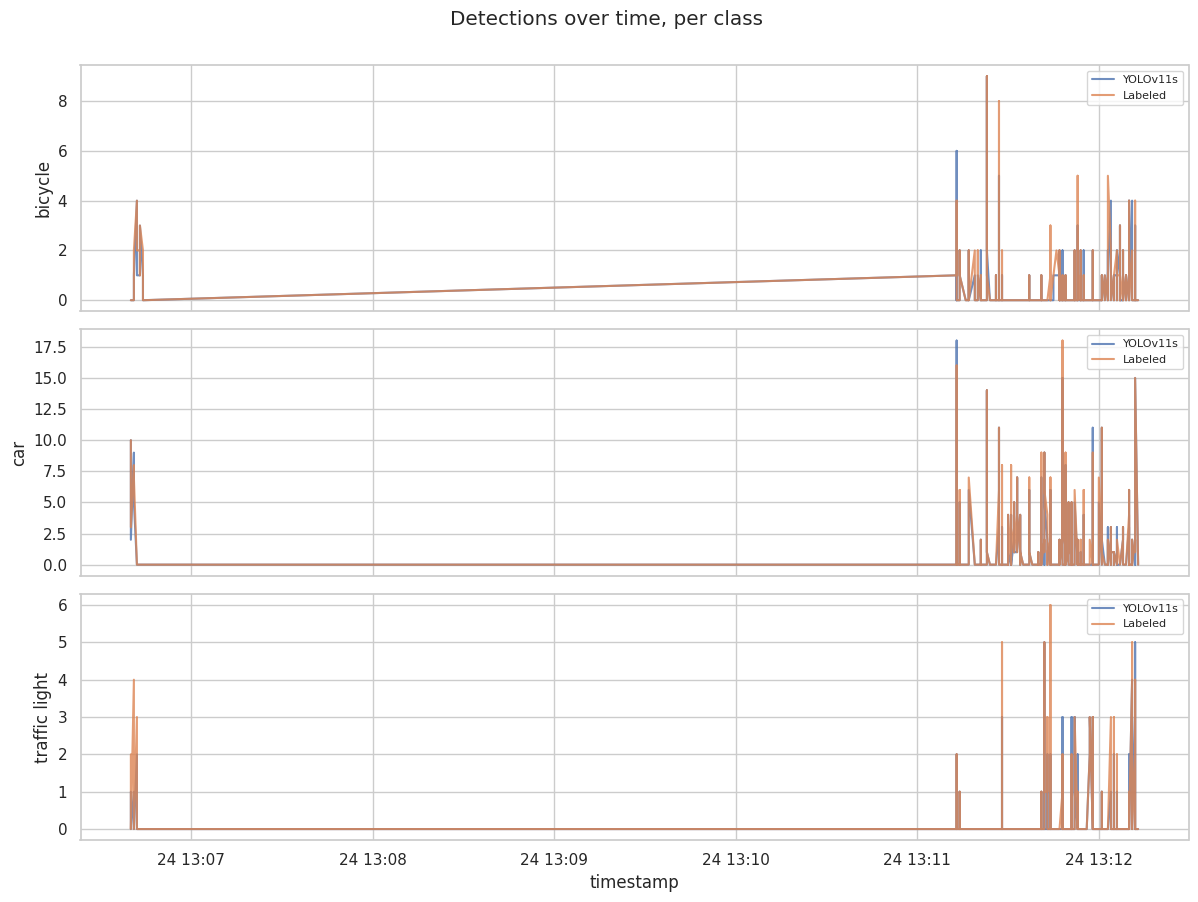

In [13]:
df_sorted = df.sort_values("timestamp")

fig, axes = plt.subplots(len(class_cols), 1, figsize=(12, 3 * len(class_cols)), sharex=True)
if len(class_cols) == 1:
    axes = [axes]

for ax, c in zip(axes, class_cols):
    ax.plot(df_sorted["timestamp"], df_sorted[f"{c}_a"], label=LABEL_A, alpha=0.8)
    ax.plot(df_sorted["timestamp"], df_sorted[f"{c}_b"], label=LABEL_B, alpha=0.8)
    ax.set_ylabel(c)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("timestamp")
fig.suptitle("Detections over time, per class", y=1.0)
plt.tight_layout()
plt.show()

## 10. Summary

- `totals` — total objects detected per class, per model
- `stats_df` — MAE / RMSE / correlation / exact-match rate per class
- `worst_frames` — frames with the biggest overall disagreement (worth spot-checking visually)

Feel free to export any of these tables, e.g.:
```python
stats_df.to_csv("agreement_stats.csv")
worst_frames.to_csv("worst_frames.csv", index=False)
```

In [14]:
print("=== Agreement statistics summary ===")
display(stats_df)

print("\n=== Class totals summary ===")
display(totals)

=== Agreement statistics summary ===


,MAE,mean_signed_diff,RMSE,pearson_r,exact_match_rate
class,,,,,
bicycle,0.120,0.066,0.451,0.806,0.909
car,0.281,0.215,0.796,0.952,0.818
traffic light,0.054,0.022,0.300,0.873,0.960



=== Class totals summary ===


,YOLOv11s,Labeled,diff (B-A),pct_diff (%)
bicycle,189,255,66,34.9
car,1075,1290,215,20.0
traffic light,110,132,22,20.0


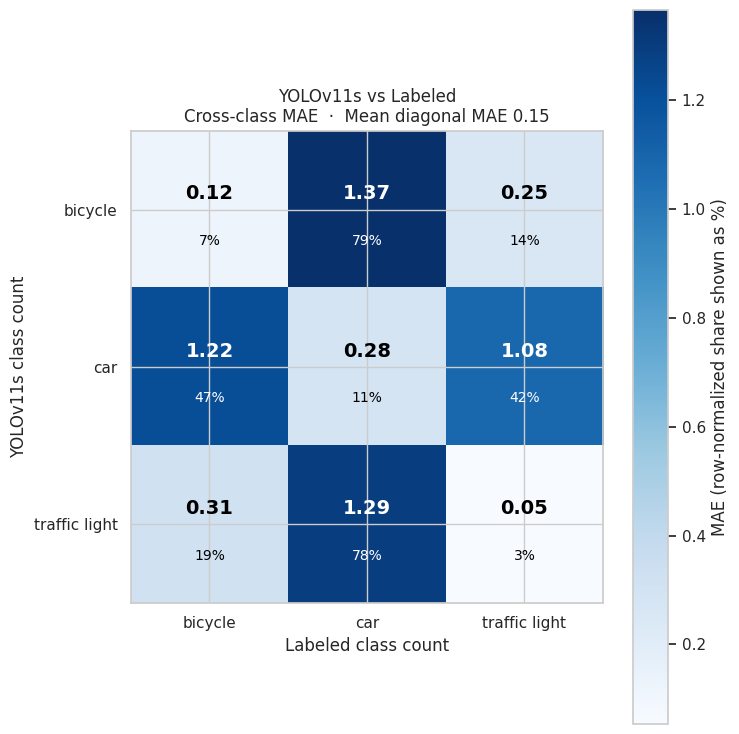

In [15]:
import matplotlib.pyplot as plt
import numpy as np

n = len(class_cols)
mae_grid = np.zeros((n, n))

for i, ci in enumerate(class_cols):       # row = "ground truth"-ish: Model A's count of class ci
    for j, cj in enumerate(class_cols):   # col = Model B's count of class cj
        mae_grid[i, j] = (df[f"{ci}_a"] - df[f"{cj}_b"]).abs().mean()

diag_mean_mae = np.mean([mae_grid[i, i] for i in range(n)])

fig, ax = plt.subplots(figsize=(2.5 * n, 2.5 * n))
im = ax.imshow(mae_grid, cmap="Blues")

for i in range(n):
    row_total = mae_grid[i, :].sum()
    for j in range(n):
        share = mae_grid[i, j] / row_total * 100 if row_total > 0 else 0
        color = "white" if mae_grid[i, j] > mae_grid.max() * 0.6 else "black"
        ax.text(j, i - 0.1, f"{mae_grid[i, j]:.2f}", ha="center", va="center",
                fontsize=14, fontweight="bold", color=color)
        ax.text(j, i + 0.2, f"{share:.0f}%", ha="center", va="center",
                fontsize=10, color=color)

ax.set_xticks(range(n)); ax.set_xticklabels(class_cols)
ax.set_yticks(range(n)); ax.set_yticklabels(class_cols)
ax.set_xlabel(f"{LABEL_B} class count")
ax.set_ylabel(f"{LABEL_A} class count")
ax.set_title(f"{LABEL_A} vs {LABEL_B}\nCross-class MAE  ·  Mean diagonal MAE {diag_mean_mae:.2f}")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("MAE (row-normalized share shown as %)")

plt.tight_layout()
plt.show()